In [1]:
import qiskit_metal as metal

In [2]:
%metal_print Create a QComponent - Basic

We will start by going over the sample `my_qcomponent` in `qiskit_metal.qlibrary.user_components` as a basis, which we will walk through below. 

In [3]:
from qiskit_metal import draw, Dict 
from qiskit_metal.toolbox_metal import math_and_overrides 
from qiskit_metal.qlibrary.core import QComponent 

`MyQComponent` creates a simple rectangle of a variable width, height, position, and orientation

In [4]:
class MyQComponent(QComponent):

    # Default drawing options 
    default_options = Dict(
        width='500um', 
        height='300um', 
        pos_x='0um', 
        pos_y='0um', 
        orientation='0', 
        layer='1', 
    )

    # Name prefix of component, if user doesn't provide a name 
    # Component Metadata 
    component_metadata = Dict(
        short_name='component', 
        _qgeometry_table_poly='True', 
    )

    def make(self): 
        """ Convert self.options into QGeometry. """ 

        p = self.parse_otions() 

        rect = draw.rectangle(p.width, p.height, p.pos_x, p.pos_y) 
        rect = draw.rotate(rect, p.orientation) 
        rect = draw.translate(rec, p.pos_x, p.pos_y) 

        geom = {'my_polygon': rect} 
        self.add_qgeometry('poly', geom, layer=p.layer, subtract=False) 
        return 
    

`default_options` is a dictionary to be included in the class of all components. 
The keywords, of type string, in the default dictionary are the parameters the front-end user is allowed to modify. The keywords in the above indicate the width and height can be modified via the component options, but have a default value of 500um and 300um respectively. The position and orientation can also be modified. 

The `layer` is an expected keyword in a default dictionary as it's used by renderers to help determine further properties of the `qgeometry` of the component when rendered. 

`component_metadata` is a dictionary which contains some important pieces of information, such as the default/shorthand name of the component `short_name`, or indicating what types of qgeometry tables are included in this component, e.g. 

`_qgeometry_table_poly='True'`. The `component_metadata` must contain the flags for each type of qgeometry table being used via `add_qgeometry` methods at the end of the `make()` function, in order for renderer options to be updated correctly. Currently the options are: 

`_qgeometry_table_path = 'True'` 

`_qgeometry_table_poly = 'True'`

`_qgeometry_table_junction = 'True'`

The `make()` method is where the actual generation of the component's layout is written. 

In [5]:
%metal_print The make() method

A good first line is `p=self.parse_options()`. This translates the keywords from self.options from strings into their appropriate values. 

Following this, all code to generate the shapely geometries used to represent the circuit layout should be written via the `draw` module or directly. It is good practice to play around with the geometries in a jupyter notebook first for quick visual feedback. 

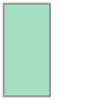

In [6]:
draw.rectangle(1, 2, 0, 0)

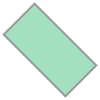

In [7]:
draw.rotate(draw.rectangle(1, 2, 0, 0), 45)

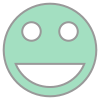

In [8]:
face = draw.shapely.geometry.Point(0, 0).buffer(1)
eye = draw.shapely.geometry.Point(0, 0).buffer(0.2) 
eye1 = draw.translate(eye, -0.4, +0.4) 
eye2 = draw.translate(eye, +0.4, +0.4) 

smile = draw.shapely.geometry.Point(0, 0).buffer(0.8) 
cut_sq = draw.shapely.geometry.box(-1, -0.3, 1, 1) 
smile = draw.subtract(smile, cut_sq)

face = draw.subtract(face, smile) 
face = draw.subtract(face, eye1) 
face = draw.subtract(face, eye2) 

face

Once you are happy with your geometries, and have them properly parameterized to allow the front end users as much customization of your component as you wish, it is time to convert the geometries into Metal `qgeometries`  via `add_qgeometry`. 

In [9]:
import qiskit_metal as metal 
?metal.qlibrary.core.QComponent.add_qgeometry

Signature:
metal.qlibrary.core.QComponent.add_qgeometry(
    self,
    kind: str,
    geometry: dict,
    subtract: bool = False,
    helper: bool = False,
    layer: typing.Union[int, str] = None,
    chip: str = None,
    **kwargs,
)
Docstring:
Add QGeometry.

Takes any additional options in options.

Args:
    kind (str): The kind of QGeometry, such as 'path', 'poly', etc.
                All geometry in the dictionary should have the same kind,
                such as Polygon or LineString.
    geometry (Dict[BaseGeometry]): Key-value pairs of name of the geometry
        you want to add and the value should be a shapely geometry object, such
        as a Polygon or a LineString.
    subtract (bool): Subtract from the layer.  Defaults to False.
    helper (bool): Is this a helper object. If true, subtract must be false
                   Defaults to False.
    layer (int, str): The layer to which the set of QGeometry will belong
                      Defaults to None, which is conv

`add_qgeometry` is the method by which the shapely geometries drawn are converted into Metal qgeometries, the format which allows for the easy translatability betweeen different renderers and the variable representation of quantum elements such as Josephson junctions. 

Currently there are three kinds of qgeometries, `path`, `poly`, and `junction`. `path` -> shapely LineString. `poly` -> any other shapely geometry. `junction` -> shapely LineString. 

Both `path and `junction` also take an input of `width` which is added to the qgeometry table to inform renderers of, as an example, how much to buffer the LineString of a cpw transmission line to turn it into a proper 2D sheet. 

`subtract` indicates the qgeometry to be subtracted from the ground plane of that layer #. A ground plane is automatically included for that layer at the dimension of the chip size if any qgeometry has `subtract = True`. As an example, a cpw transmission line's dielectric gap could be drawn using the same LineString as previously, having the `width = cpw_width + 2*cpw_gap` and setting `subtract = True`. 

`fillet` is an option that informs a renderer that the verticies of this qgeometry are to be filleted by that value (e.g. `fillet = '100um'`) 

### add_pin

In [10]:
?metal.qlibrary.core.QComponent.add_pin

Signature:
metal.qlibrary.core.QComponent.add_pin(
    self,
    name: str,
    points: numpy.ndarray,
    width: float,
    input_as_norm: bool = False,
    chip: str = None,
    gap: float = None,
)
Docstring:
Adds a pin from two points which are normal/tangent to the intended
plane of the pin. The normal should 'point' in the direction of
intended connection. Adds the new pin as a subdictionary to parent
component's pins dictionary.

Args:
    * name (str): name of the pin
    * points (numpy.ndarray): [[x1,y1],[x2,y2]] for the normal/tangent line
    * width (float): the width of the intended connection (eg. qubit bus pad arm)
    * input_as_norm (bool): Indicates if the points are tangent or normal to the pin plane.
      Defaults to False.. Make True for normal.
    * parent (Union[int,]): The id of the parent component.
    * chip (str): the name of the chip the pin is located on. Defaults to None, which is 
    converted to self.options.chip.
    * gap (float): the dielectric g

The final step of making a QComponent is adding pins. This is not necessary but to have functionality you want to indicate where the "ports" of your component are. 


Pins can be added from two coordinates indicating either an orthogonal vector to the port plane of your component, or a tangent to the port plane of your component. For the former, you want the vector to be pointing to the middle point of your intended plane, with the latter being across the length of your intended plane. 

The `width` should be the size of the plane, say in the case of a CPW transmission line, the trace width, with the `gap` following the same logic. 

## Example 

Below is a simple QComponent that implements everything reviewed so far. 

In [11]:
from qiskit_metal import draw, Dict 
from qiskit_metal.toolbox_metal import math_and_overrides 
from qiskit_metal.qlibrary.core import QComponent 

In [12]:
class MySimpleGapCapacitor(QComponent): 
    """
    Inherits `QComponent` class. 

    Description: 
        A simple CPW style gap capacitor, with endcap islands each coupled to their own 
        cpw transmission line that ends in a pin. 

    Options: 
        * cpw_width: width of the cpw trace of the transmission line 
        * cpw_gap: dielectric gap of the cpw transmission line 
        * cap_width: width of the gap capacitor (size of the charge islands) 
        * cap_gap: dielectric space between the two islands 
        * pos_x/_y: position of the capacitor on chip 
        * orientation: 0-> is parallel to the x_axis, with orientation (in degrees) counterclockwise 
        * layer: the layer number for the layout
        
        
    """

    # Default drawing options 
    default_options = Dict(
        cpw_width='15um', 
        cpw_gap='9um', 
        cap_width='35um', 
        cap_gap='3um', 
        pos_x='0um', 
        pos_y='0um', 
        orientation='0', 
        layer='1', 
    )

    # Component metadata 
    # Name prefix of component, if user doesn't provide a name
    component_metadata = Dict( 
        short_name='component', 
        _qgeometry_table_poly='True', 
        _qgeometry_table_path='True', 
    )

    def make(self):
        """Convert self.options into QGeometry."""

        p = self.parse_options()  # Parse the string options into numbers

        pad = draw.rectangle(p.cpw_width, p.cap_width, 0, 0)
        pad_left = draw.translate(pad,-(p.cpw_width+p.cap_gap)/2,0)
        pad_right = draw.translate(pad,(p.cpw_width+p.cap_gap)/2,0)
        pad_etch = draw.rectangle(2*p.cpw_gap+2*p.cpw_width+p.cap_gap,2*p.cpw_gap+p.cap_width)
        cpw_left = draw.shapely.geometry.LineString([[-(p.cpw_width+p.cap_gap/2),0],[-(p.cpw_width*3 +p.cap_gap/2),0]])
        cpw_right = draw.shapely.geometry.LineString([[(p.cpw_width+p.cap_gap/2),0],[(p.cpw_width*3 +p.cap_gap/2),0]])

        geom_list = [pad_left,pad_right,cpw_left,cpw_right,pad_etch]
        geom_list = draw.rotate(geom_list,p.orientation)
        geom_list = draw.translate(geom_list,p.pos_x,p.pos_y)
        [pad_left,pad_right,cpw_left,cpw_right,pad_etch] = geom_list

        self.add_qgeometry('path', {'cpw_left':cpw_left, 'cpw_right':cpw_right}, layer=p.layer, width = p.cpw_width)
        self.add_qgeometry('path', {'cpw_left_etch':cpw_left, 'cpw_right_etch':cpw_right}, layer=p.layer, width = p.cpw_width+2*p.cpw_gap, subtract=True)
        self.add_qgeometry('poly', {'pad_left':pad_left, 'pad_right':pad_right}, layer=p.layer)
        self.add_qgeometry('poly', {'pad_etch':pad_etch}, layer=p.layer, subtract=True)

        self.add_pin('cap_left', cpw_left.coords, width = p.cpw_width, gap = p.cpw_gap, input_as_norm=True)
        self.add_pin('cap_right', cpw_right.coords, width = p.cpw_width, gap = p.cpw_gap, input_as_norm=True)
        return 

In [13]:
design = metal.designs.DesignPlanar() 
gui = metal.MetalGUI(design) 
design.overwrite_enabled = True 

11:35AM 24s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 177 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



11:35AM 24s INFO [delete_component]: Called delete_component my_cap1, but such a component is not in the design cache dictionary of components.


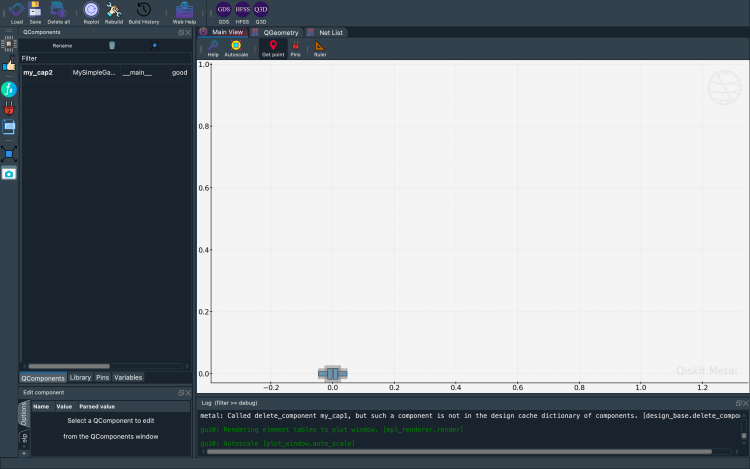

In [14]:
try: 
    design.delete_component('my_cap1')
except NameError: pass

my_cap = MySimpleGapCapacitor(design, 'my_cap1') 
gui.rebuild()
gui.autoscale() 
gui.screenshot()

In [15]:
gui.main_window.close()

True